# YOLO26 Indonesian Food Detection Training Notebook

Program training untuk mendeteksi makanan Indonesia menggunakan YOLO26.

## Quick Start Guide

### 1. Edit Configuration
Ubah parameter training di cell "TRAINING CONFIGURATION":
- `DATASET_PATH` - Path ke folder dataset Anda
- `BASE_MODEL` - Model YOLO yang akan digunakan
- `EPOCHS` - Jumlah epoch training
- `BATCH_SIZE` - Batch size sesuai GPU memory
- `OUTPUT_NAME` - Nama output model

### 2. Run All Cells
Setelah konfigurasi, jalankan semua cell secara berurutan:
- Install dependencies
- Load libraries
- Check dataset
- Update data.yaml
- Verify dataset quality
- Start Training

### 3. Monitor Training
Training akan berjalan dan menyimpan model terbaik di: `{OUTPUT_PROJECT}/{OUTPUT_NAME}/weights/best.pt`

## Dataset Requirements:
- Format: YOLO (folder train/valid/test)
- Classes: 21 kelas makanan (Ayam Goreng, Bakso, dll)

## 1. Install Dependencies

## TRAINING CONFIGURATION
Ubah parameter di cell berikutnya untuk konfigurasi training Anda:

In [1]:
# TRAINING CONFIGURATION

# Dataset Configuration
DATASET_PATH = r"..\data\Food Recognation.v4-roboflow-instant-2--eval-.yolo26"

# Model Configuration
BASE_MODEL = "yolo26s.pt"

# Training Parameters
EPOCHS = 100
IMAGE_SIZE = 640
BATCH_SIZE = 8

# Output Configuration
OUTPUT_NAME = "indonesian_food_yolo26"
OUTPUT_PROJECT = "runs/detect"

# Device Configuration
DEVICE = "0"
WORKERS = 4

# Augmentation Settings
AUGMENT_HSV_H = 0.015
AUGMENT_HSV_S = 0.7
AUGMENT_HSV_V = 0.4
AUGMENT_DEGREES = 10.0
AUGMENT_TRANSLATE = 0.1
AUGMENT_SCALE = 0.5
AUGMENT_MOSAIC = 1.0
AUGMENT_MIXUP = 0.1

# Optimizer Settings
LEARNING_RATE = 0.01
WEIGHT_DECAY = 0.0005
PATIENCE = 20

# Validation & Saving
SAVE_PERIOD = 10
VAL_ENABLED = True
PLOTS_ENABLED = True
AMP_ENABLED = True

print("Training Configuration Loaded")
print(f"Dataset:      {DATASET_PATH}")
print(f"Base Model:   {BASE_MODEL}")
print(f"Epochs:       {EPOCHS}")
print(f"Image Size:   {IMAGE_SIZE}")
print(f"Batch Size:   {BATCH_SIZE}")
print(f"Output:       {OUTPUT_PROJECT}/{OUTPUT_NAME}")
print(f"Device:       {DEVICE}")

Training Configuration Loaded
Dataset:      ..\data\Food Recognation.v4-roboflow-instant-2--eval-.yolo26
Base Model:   yolo26s.pt
Epochs:       100
Image Size:   640
Batch Size:   8
Output:       runs/detect/indonesian_food_yolo26
Device:       0


In [2]:
# !pip install ultralytics opencv-python-headless pillow numpy matplotlib pyyaml

## 2. Import Libraries

In [3]:
%matplotlib inline

import cv2
import numpy as np
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display, Image, clear_output
import time

print("Libraries imported successfully!")
print("Matplotlib backend configured for Jupyter Notebook")

Libraries imported successfully!
Matplotlib backend configured for Jupyter Notebook


## 9. Check Dataset Structure

In [4]:
from pathlib import Path
import shutil

dataset_path = Path(DATASET_PATH)

print("Checking Dataset Structure")

if dataset_path.exists():
    print(f"Dataset found: {dataset_path}")
    
    data_yaml = dataset_path / "data.yaml"
    if data_yaml.exists():
        print(f"Configuration file: {data_yaml}")
        with open(data_yaml, 'r') as f:
            print("\nDataset Configuration Content:")
            print("-" * 40)
            print(f.read())
            print("-" * 40)
    else:
        print("data.yaml not found.")
    
    splits = ['train', 'valid', 'val', 'test']
    for split in splits:
        split_images = dataset_path / split / "images"
        split_labels = dataset_path / split / "labels"
        
        if split_images.exists():
            image_count = len(list(split_images.glob("*.*")))
            print(f"\n{split.upper()}:")
            print(f"   Images: {image_count}")
            
            if split_labels.exists():
                label_count = len(list(split_labels.glob("*.txt")))
                print(f"   Labels: {label_count}")
        else:
            if split != 'val' and split != 'valid':
                 pass # silently ignore either val or valid
else:
    print(f"Dataset not found: {dataset_path}")

Checking Dataset Structure
Dataset found: ..\data\Food Recognation.v4-roboflow-instant-2--eval-.yolo26
Configuration file: ..\data\Food Recognation.v4-roboflow-instant-2--eval-.yolo26\data.yaml

Dataset Configuration Content:
----------------------------------------
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 21
names:
- Ayam Goreng
- Bakso
- Bubur Ayam
- Cakwe
- Dadar Gulung
- Ikan Goreng
- Klepon
- Lontong Sayur
- Martabak Manis
- Mie Goreng
- Nasi Padang
- Rendang
- Risol
- Rujak
- Rujak Buah
- Sayur Asem
- Soto Ayam
- Nasi Goreng
- Pecel Lele
- Rawon
- Sate
roboflow:
  workspace: jenny-cfchd
  project: food-recognation-1x0db
  version: 4
  license: CC BY 4.0
  url: https://universe.roboflow.com/jenny-cfchd/food-recognation-1x0db/dataset/4
path: c:/Users/fadel/Fadel/Code/Senpro/Senpro-25/scripts/../data/Food Recognation.v4-roboflow-instant-2--eval-.yolo26

----------------------------------------

TRAIN:
   Images: 2579
   Labels: 2579

VALID:
   Images: 737

### Update data.yaml untuk Absolute Path

In [5]:
import os
from pathlib import Path
import yaml

dataset_path = Path(DATASET_PATH).absolute()
data_yaml_path = dataset_path / "data.yaml"

if data_yaml_path.exists():
    with open(data_yaml_path, 'r') as f:
        config = yaml.safe_load(f)
    
    config['path'] = str(dataset_path).replace('\\', '/')
    
    if 'valid' in config and 'val' not in config:
        config['val'] = config.pop('valid')
        
    with open(data_yaml_path, 'w') as f:
        yaml.safe_dump(config, f, sort_keys=False)
        
    print("data.yaml updated successfully for YOLO execution.")
    print(f"Config file: {data_yaml_path}")
else:
    print(f"Error: {data_yaml_path} does not exist.")

data_yaml_for_training = str(data_yaml_path)

data.yaml updated successfully for YOLO execution.
Config file: c:\Users\fadel\Fadel\Code\Senpro\Senpro-25\scripts\..\data\Food Recognation.v4-roboflow-instant-2--eval-.yolo26\data.yaml


### Verify Dataset Quality

Dataset Quality Check

TRAIN:
  Total images: 2579
  Total labels: 2579

VALID:
  Total images: 737
  Total labels: 737

TEST:
  Total images: 368
  Total labels: 368


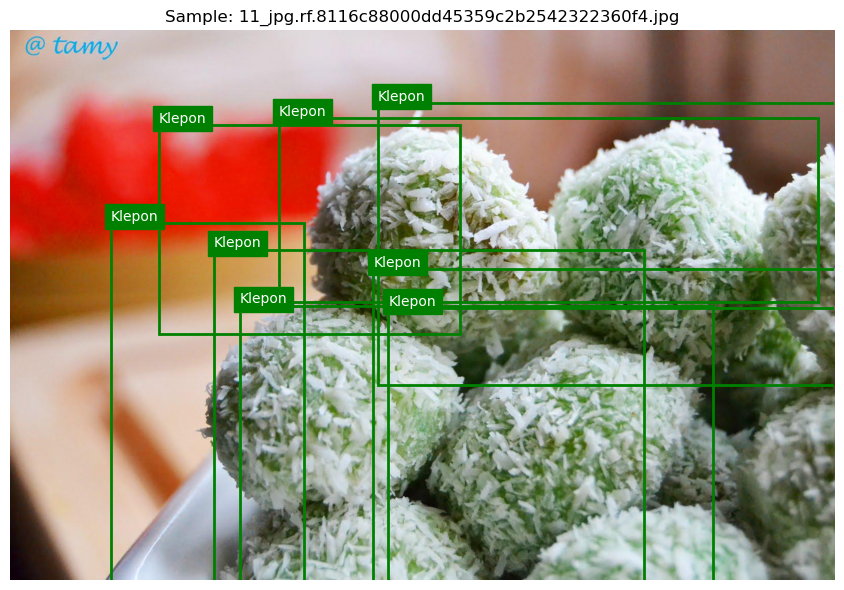


Dataset verification completed.


In [6]:
# Verify Dataset Quality
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import yaml

dataset_path = Path(DATASET_PATH)
data_yaml_path = dataset_path / "data.yaml"

class_names = []
if data_yaml_path.exists():
    with open(data_yaml_path, 'r') as f:
        config = yaml.safe_load(f)
        class_names = config.get('names', [])

print("Dataset Quality Check")

splits = ['train', 'valid', 'val', 'test']
for split in splits:
    split_images = dataset_path / split / "images"
    split_labels = dataset_path / split / "labels"
    
    if not split_images.exists():
        continue
    
    image_files = list(split_images.glob("*.jpg")) + list(split_images.glob("*.png"))
    label_files = list(split_labels.glob("*.txt"))
    
    print(f"\n{split.upper()}:")
    print(f"  Total images: {len(image_files)}")
    print(f"  Total labels: {len(label_files)}")

train_images = dataset_path / "train" / "images"
train_labels = dataset_path / "train" / "labels"

if train_images.exists():
    image_files = list(train_images.glob("*.jpg")) + list(train_images.glob("*.png"))
    if image_files:
        sample_image_path = image_files[0]
        sample_label_path = train_labels / (sample_image_path.stem + '.txt')
        
        image = cv2.imread(str(sample_image_path))
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            h, w = image.shape[:2]
            
            fig, ax = plt.subplots(1, figsize=(10, 6))
            ax.imshow(image)
            
            if sample_label_path.exists():
                with open(sample_label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            class_id = int(parts[0])
                            x_center, y_center, width, height = map(float, parts[1:5])
                            
                            x1 = int((x_center - width/2) * w)
                            y1 = int((y_center - height/2) * h)
                            box_w = int(width * w)
                            box_h = int(height * h)
                            
                            rect = patches.Rectangle((x1, y1), box_w, box_h, linewidth=2, edgecolor='green', facecolor='none')
                            ax.add_patch(rect)
                            
                            c_name = class_names[class_id] if class_id < len(class_names) else f'class_{class_id}'
                            ax.text(x1, y1-5, c_name, color='white', backgroundcolor='green', fontsize=10)
            
            ax.axis('off')
            plt.title(f'Sample: {sample_image_path.name}')
            plt.tight_layout()
            plt.show()

print("\nDataset verification completed.")

### Train YOLO Model

In [7]:
import torch

print("=" * 60)
print("PyTorch CUDA Verification")
print("=" * 60)
print(f"PyTorch version:     {torch.__version__}")
print(f"CUDA available:      {torch.cuda.is_available()}")
print(f"CUDA version:        {torch.version.cuda}")
print(f"cuDNN version:       {torch.backends.cudnn.version()}")
print(f"Device count:        {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"\nGPU Information:")
    print(f"  Device name:       {torch.cuda.get_device_name(0)}")
    print(f"  Device capability: {torch.cuda.get_device_capability(0)}")
    print(f"  Total memory:      {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"  Current device:    cuda:{torch.cuda.current_device()}")
    
    # Test tensor operation on GPU
    test_tensor = torch.rand(100, 100).cuda()
    print(f"\n✓ GPU tensor test:   SUCCESS")
    print(f"  Tensor device:     {test_tensor.device}")
else:
    print("\n✗ CUDA not available! Please check installation.")

print("=" * 60)

PyTorch CUDA Verification
PyTorch version:     2.10.0+cu128
CUDA available:      True
CUDA version:        12.8
cuDNN version:       91002
Device count:        1

GPU Information:
  Device name:       NVIDIA GeForce GTX 1650 Ti
  Device capability: (7, 5)
  Total memory:      4.00 GB
  Current device:    cuda:0

✓ GPU tensor test:   SUCCESS
  Tensor device:     cuda:0


In [ ]:
# START TRAINING
from pathlib import Path
from ultralytics import YOLO

dataset_path = Path(DATASET_PATH).absolute()
data_yaml_path = str(dataset_path / "data.yaml")

print("Starting YOLO26 Training")
print(f"Dataset:      {dataset_path}")
print(f"Config:       {data_yaml_path}")
print(f"Base Model:   {BASE_MODEL}")
print(f"Output:       {OUTPUT_PROJECT}/{OUTPUT_NAME}")

model = YOLO(BASE_MODEL)

results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    hsv_h=AUGMENT_HSV_H,
    hsv_s=AUGMENT_HSV_S,
    hsv_v=AUGMENT_HSV_V,
    degrees=AUGMENT_DEGREES,
    translate=AUGMENT_TRANSLATE,
    scale=AUGMENT_SCALE,
    mosaic=AUGMENT_MOSAIC,
    mixup=AUGMENT_MIXUP,
    optimizer='auto',
    lr0=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    name=OUTPUT_NAME,
    project=OUTPUT_PROJECT,
    exist_ok=True,
    device=DEVICE,
    workers=WORKERS,
    val=VAL_ENABLED,
    plots=PLOTS_ENABLED,
    save=True,
    save_period=SAVE_PERIOD,
    amp=AMP_ENABLED,
    verbose=True,
    cache=False
)

print("\nTraining Completed.")

print("\nEvaluating model on validation set...")
metrics = model.val()
print(f"Validation mAP50: {metrics.box.map50:.3f}")

best_model_path = f"{OUTPUT_PROJECT}/{OUTPUT_NAME}/weights/best.pt"
print(f"\nBest model saved to: {best_model_path}")

Starting YOLO26 Training
Dataset:      c:\Users\fadel\Fadel\Code\Senpro\Senpro-25\scripts\..\data\Food Recognation.v4-roboflow-instant-2--eval-.yolo26
Config:       c:\Users\fadel\Fadel\Code\Senpro\Senpro-25\scripts\..\data\Food Recognation.v4-roboflow-instant-2--eval-.yolo26\data.yaml
Base Model:   yolo26s.pt
Output:       runs/detect/indonesian_food_yolo26
Ultralytics 8.4.23  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\fadel\Fadel\Code\Senpro\Senpro-25\scripts\..\data\Food Recognation.v4-roboflow-instant-2--eval-.yolo26\data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasi

KeyboardInterrupt: 

: 

## 12. Evaluate Model on Test Set

Evaluate trained model pada test set untuk melihat performa final.

In [ ]:
from pathlib import Path
from ultralytics import YOLO
import yaml

dataset_path = Path(DATASET_PATH).absolute()
data_yaml_path = str(dataset_path / "data.yaml")

best_model_path = f"{OUTPUT_PROJECT}/{OUTPUT_NAME}/weights/best.pt"
model = YOLO(best_model_path)

print("Model Evaluation on Test Set")
print(f"Model: {best_model_path}")
print(f"Dataset: {data_yaml_path}")

test_images = dataset_path / "test" / "images"
if test_images.exists():
    test_count = len(list(test_images.glob("*.jpg")) + list(test_images.glob("*.png")))
    print(f"Test images: {test_count}")
    print("Running evaluation...")
    
    test_metrics = model.val(data=data_yaml_path, split='test')
    
    print("\nTest Set Results:")
    print(f"mAP50:     {test_metrics.box.map50:.4f}")
    print(f"mAP50-95:  {test_metrics.box.map:.4f}")
    print(f"Precision: {test_metrics.box.mp:.4f}")
    print(f"Recall:    {test_metrics.box.mr:.4f}")
    
    class_names = []
    with open(data_yaml_path, 'r') as f:
        config = yaml.safe_load(f)
        class_names = config.get('names', [])
        
    print("\nPer-Class Performance:")
    if hasattr(test_metrics.box, 'ap_class_index'):
        for i, idx in enumerate(test_metrics.box.ap_class_index):
            if i < len(test_metrics.box.ap):
                c_name = class_names[idx] if idx < len(class_names) else str(idx)
                print(f"  {c_name[:15]:15s} - AP50: {test_metrics.box.ap50[i]:.4f}")
else:
    print("\nTest set not found!")
    print("\nRunning validation on val set instead...")
    
    val_metrics = model.val(data=data_yaml_path)
    print("\nValidation Set Results:")
    print(f"mAP50:     {val_metrics.box.map50:.4f}")
    print(f"mAP50-95:  {val_metrics.box.map:.4f}")

Model Evaluation on Test Set
Model: runs\detect\runs\detect\helmet_detector_yolo26_v4\weights\best.pt
Dataset: helmet_detection.v5i.yolo26\data.yaml
Test images: 77

Running evaluation...
Ultralytics 8.4.7  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
YOLO26s summary (fused): 122 layers, 9,466,341 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1139.8978.4 MB/s, size: 614.1 KB)
val: Scanning C:\Users\fadel\Fadel\Code\Magang\model_obj_detection\helmet_detection.v5i.yolo26\test\labels.cache... 77 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 77/77  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 555, len(boxes) = 651. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━